In [9]:
import numpy as np
import matplotlib.pyplot as plt

# --- parameters ---
mass  = 70.0   # kg
v0    = 1.5    # desired speed (m/s)
tau   = 0.5    # relaxation time (s)
dt    = 0.05   # time step (s)
t_end = 10.0    # total simulation time (s)

# --- initial state ---
pos = np.array([0.0, 0.0])   # person starts at origin
vel = np.array([0.0, 0.0])   # standing still

# --- target (the exit) ---
target = np.array([10.0, 0.0])

In [2]:
def desired_direction(pos, target):
    diff = target - pos
    dist = np.linalg.norm(diff)   # distance to target
    return diff / dist            # unit vector

In [3]:
def self_driving_force(vel, pos, target, mass, v0, tau):
    e0 = desired_direction(pos, target)
    desired_vel = v0 * e0
    return mass * (desired_vel - vel) / tau

In [4]:
times  = []
speeds = []

t = 0.0
while t < t_end:
    # compute force
    f = self_driving_force(vel, pos, target, mass, v0, tau)
    
    # update velocity  (Newton: a = F/m, so dv = a*dt)
    vel = vel + (f / mass) * dt
    
    # update position
    pos = pos + vel * dt
    
    # record
    times.append(t)
    speeds.append(np.linalg.norm(vel))
    
    t += dt

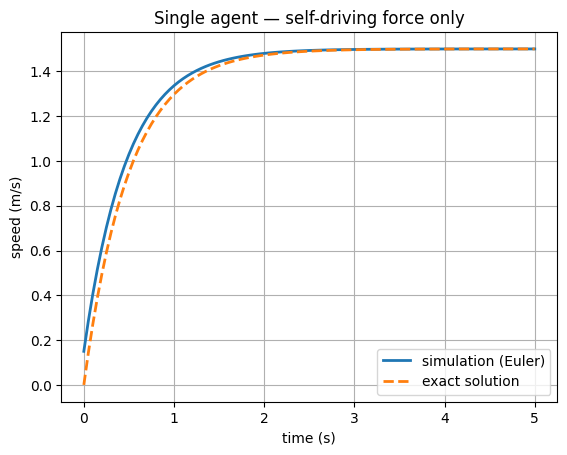

In [5]:
# exact analytic solution
t_arr   = np.array(times)
v_exact = v0 * (1 - np.exp(-t_arr / tau))

plt.plot(t_arr, speeds,  label='simulation (Euler)', linewidth=2)
plt.plot(t_arr, v_exact, label='exact solution',     linewidth=2, linestyle='--')
plt.xlabel('time (s)')
plt.ylabel('speed (m/s)')
plt.legend()
plt.title('Single agent — self-driving force only')
plt.grid(True)
plt.show()

In [6]:
def repulsion_force(pos_i, pos_j, vel_i, vel_j):
    # --- geometry ---
    diff = pos_i - pos_j
    d    = np.linalg.norm(diff)     # distance between centers
    r_ij = 0.5                       # sum of radii (0.25m each)
    n    = diff / d                  # unit vector from j toward i

    # --- parameters ---
    A = 2000.0      # repulsion strength (N)
    B = 0.08        # repulsion range (m)
    k = 120000.0    # body compression stiffness
    
    # --- contact function g(x) ---
    overlap = r_ij - d
    g = max(overlap, 0.0)           # zero if not touching

    # --- three sub-terms ---
    psychological = A * np.exp(overlap / B) * n
    compression   = k * g * n

    return psychological + compression

In [10]:
# --- initial states ---
pos1 = np.array([0.0,  0.3])   # person 1, above center
pos2 = np.array([0.0, -0.3])   # person 2, below center  # person 2, ahead and slightly below
vel1 = np.array([0.0,  0.0])
vel2 = np.array([0.0,  0.0])

target = np.array([10.0, 0.0])

# --- recording ---
traj1 = [pos1.copy()]
traj2 = [pos2.copy()]
times = []

t = 0.0
while t < t_end:
    # self-driving forces
    f1_drive = self_driving_force(vel1, pos1, target, mass, v0, tau)
    f2_drive = self_driving_force(vel2, pos2, target, mass, v0, tau)

    # repulsion forces (symmetric: j pushes i, i pushes j)
    f_rep = repulsion_force(pos1, pos2, vel1, vel2)

    # total force on each person
    f1_total = f1_drive + f_rep
    f2_total = f2_drive - f_rep    # equal and opposite

    # update velocities
    vel1 = vel1 + (f1_total / mass) * dt
    vel2 = vel2 + (f2_total / mass) * dt

    # update positions
    pos1 = pos1 + vel1 * dt
    pos2 = pos2 + vel2 * dt

    traj1.append(pos1.copy())
    traj2.append(pos2.copy())
    times.append(t)
    t += dt

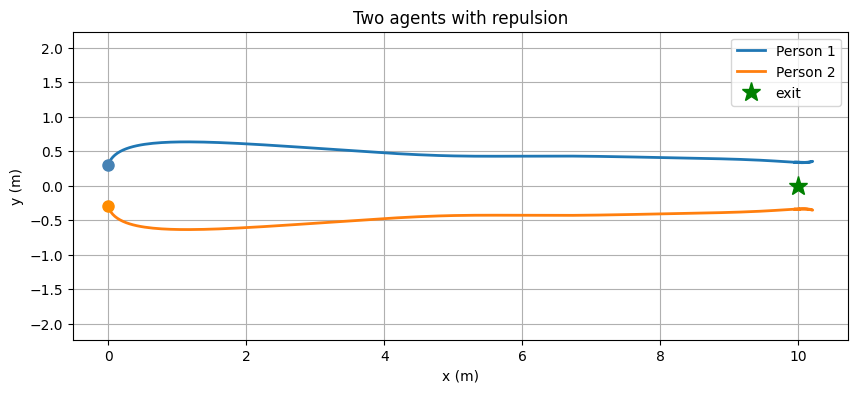

In [11]:
traj1 = np.array(traj1)
traj2 = np.array(traj2)

plt.figure(figsize=(10, 4))
plt.plot(traj1[:, 0], traj1[:, 1], label='Person 1', linewidth=2)
plt.plot(traj2[:, 0], traj2[:, 1], label='Person 2', linewidth=2)

# mark start positions
plt.plot(*traj1[0], 'o', markersize=8, color='steelblue')
plt.plot(*traj2[0], 'o', markersize=8, color='darkorange')

# mark exit
plt.plot(*target, 'g*', markersize=14, label='exit')

plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.legend()
plt.title('Two agents with repulsion')
plt.grid(True)
plt.axis('equal')
plt.show()

The new data structure
Instead of pos1, pos2, ... we have:
positions[i] is the position of person i, velocities[i] is their velocity.

In [14]:
N = 20  # number of people

# place agents in a neat grid inside the room
cols = 5
rows = 4   # 5 x 4 = 20 agents
xs = np.linspace(1, 7, cols)
ys = np.linspace(1, 5, rows)
grid_x, grid_y = np.meshgrid(xs, ys)
positions = np.column_stack([grid_x.ravel(), grid_y.ravel()])  # shape (20, 2)

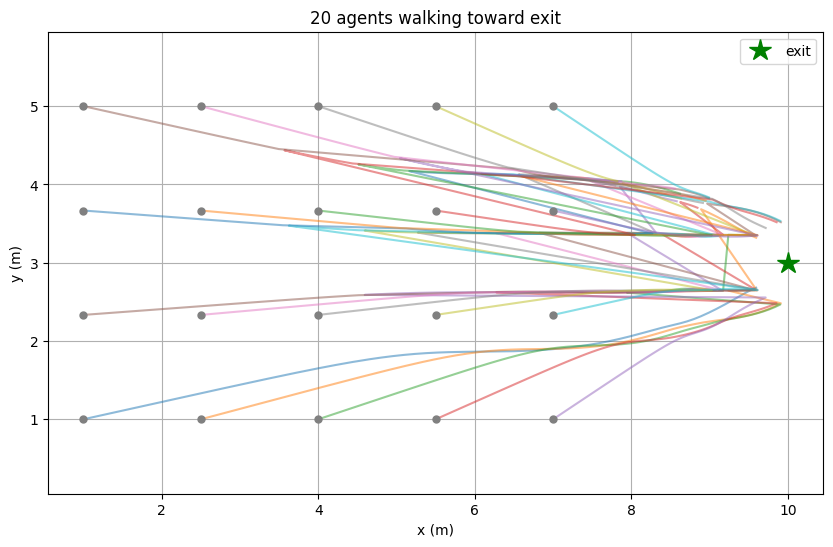

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# --- parameters ---
mass  = 70.0
v0    = 1.5
tau   = 0.5
dt    = 0.05
t_end = 15.0
N     = 20

# --- grid starting positions ---
cols = 5
rows = 4
xs = np.linspace(1, 7, cols)
ys = np.linspace(1, 5, rows)
grid_x, grid_y = np.meshgrid(xs, ys)
positions  = np.column_stack([grid_x.ravel(), grid_y.ravel()])
velocities = np.zeros((N, 2))

target = np.array([10.0, 3.0])

# --- force functions ---
def all_self_driving_forces(positions, velocities, target, mass, v0, tau):
    diff         = target - positions
    dists        = np.linalg.norm(diff, axis=1, keepdims=True)
    directions   = diff / dists
    desired_vels = v0 * directions
    return mass * (desired_vels - velocities) / tau

def all_repulsion_forces(positions):
    N = len(positions)
    F = np.zeros((N, 2))
    A, B, k, r = 2000.0, 0.08, 120000.0, 0.5
    for i in range(N):
        for j in range(N):
            if i == j:
                continue
            diff = positions[i] - positions[j]
            d    = np.linalg.norm(diff)
            if d < 1e-6:
                continue
            n       = diff / d
            overlap = r - d
            g       = max(overlap, 0.0)
            F[i]   += (A * np.exp(overlap / B) + k * g) * n
    return F

# --- time loop ---
start_pos     = positions.copy()
all_positions = [positions.copy()]

t = 0.0
while t < t_end:
    f_drive = all_self_driving_forces(positions, velocities, target, mass, v0, tau)
    f_rep   = all_repulsion_forces(positions)

    velocities += (f_drive + f_rep) / mass * dt
    positions  += velocities * dt

    reached    = np.linalg.norm(positions - target, axis=1) < 0.5
    positions  = positions[~reached]
    velocities = velocities[~reached]

    all_positions.append(positions.copy())
    t += dt

# --- plot ---
plt.figure(figsize=(10, 6))

for i in range(N):
    x_traj, y_traj = [], []
    for step in all_positions:
        if i < len(step):
            x_traj.append(step[i, 0])
            y_traj.append(step[i, 1])
    plt.plot(x_traj, y_traj, alpha=0.5)

for i in range(N):
    plt.plot(*start_pos[i], 'o', markersize=5, color='gray')

plt.plot(*target, 'g*', markersize=16, label='exit')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title(f'{N} agents walking toward exit')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

The natural next step: add a room with walls

In [22]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(10, 6))

# the scatter plot we'll update each frame
scat = ax.scatter([], [], s=100, color='steelblue', zorder=3)

ax.plot(*target, 'g*', markersize=16, label='exit')
ax.set_xlim(-1, 12)
ax.set_ylim(-1, 7)
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_title('20 agents — animated')
ax.grid(True)
ax.legend()

def update(frame):
    step = all_positions[frame]
    if len(step) > 0:
        scat.set_offsets(step)
    else:
        scat.set_offsets(np.empty((0, 2)))
    return scat,

ani = FuncAnimation(
    fig,
    update,
    frames=len(all_positions),
    interval=50,        # milliseconds between frames
    blit=True
)

plt.close()             # prevents a static plot appearing as well
HTML(ani.to_jshtml())   # renders the animation inline in Jupyter

KeyboardInterrupt: 